# Graph WaveNet for Spatio-Temporal Forecasting

Traffic sensors, weather stations, and power-grid meters are not independent
series: a jam on one road slows the next, a front that crosses one station
reaches its neighbours soon after. **Graph WaveNet** (Wu et al., 2019) models
that coupling with two ingredients. Dilated causal convolutions handle the
*temporal* axis, and a graph convolution handles the *spatial* axis, mixing
each node's hidden state with its neighbours'. Its trick is the **adaptive
adjacency matrix**: a graph built from learned node embeddings and trained
jointly with the forecaster, so you never have to supply the graph yourself.

This notebook builds a compact Graph WaveNet from scratch, trains it on a
synthetic sensor network, and runs a no-graph ablation to show the spatial
mixing earns its place. It is a teaching-scale implementation; the reference
code (https://github.com/nnzhan/Graph-WaveNet) adds a fixed distance graph,
more layers, and multi-step decoding.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)

## A synthetic sensor network

Six sensors sit in a chain: `0 -> 1 -> 2 -> 3 -> 4 -> 5`. Sensor 0 is the
source, a daily-plus-weekly oscillation. Each downstream sensor is a lagged,
smoothed copy of the one before it, plus its own noise. So every sensor
carries a delayed echo of its upstream neighbour, and a model that shares
information across sensors should forecast better than one that treats them
as independent series.

In [2]:
n_nodes = 6
T_total = 4000
t = np.arange(T_total)

src = (np.sin(2 * np.pi * t / 24)
       + 0.5 * np.sin(2 * np.pi * t / 168)
       + 0.3 * rng.standard_normal(T_total))

signals = [src]
for i in range(1, n_nodes):
    parent = signals[-1]
    delayed = np.roll(parent, 3)            # 3-step propagation lag
    child = 0.8 * delayed + 0.25 * rng.standard_normal(T_total)
    signals.append(child)

data = np.stack(signals, axis=0)[:, 10:]    # (N, T), drop roll wraparound
mean, std = data.mean(1, keepdims=True), data.std(1, keepdims=True)
data = (data - mean) / std
print(f"network: {n_nodes} sensors, {data.shape[1]} time steps after trimming")

network: 6 sensors, 3990 time steps after trimming


## Windowing

Each training sample is a window of `L` past steps for every node, paired
with the next `H` steps. The tensor layout is `(batch, channels, nodes,
time)`, the convention Graph WaveNet's 2-D convolutions expect.

In [3]:
L, H = 24, 6


def make_windows(arr):
    X, Y = [], []
    for k in range(arr.shape[1] - L - H):
        X.append(arr[:, k:k + L])
        Y.append(arr[:, k + L:k + L + H])
    X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)  # (B,1,N,L)
    Y = torch.tensor(np.array(Y), dtype=torch.float32)               # (B,N,H)
    return X, Y


split = int(0.8 * data.shape[1])
X_train, Y_train = make_windows(data[:, :split])
X_test, Y_test = make_windows(data[:, split:])
print(f"train windows {X_train.shape[0]}, test windows {X_test.shape[0]}")

train windows 3162, test windows 768


## The model

`adaptive_adj` is the heart of it: two embedding tables `E1`, `E2`, one row
per node, multiplied and passed through `relu` then `softmax`. The result is
a learned, row-normalised adjacency, trained by backprop like any other
parameter. Each layer is a WaveNet block: a dilated causal convolution with a
`tanh * sigmoid` gate, then a graph diffusion step that mixes node states
through the adjacency, plus residual and skip connections. Stacked dilations
`1, 2, 4, 8` give the temporal receptive field. The `adaptive` flag lets us
switch the learned graph off, replacing it with the identity, for the
ablation below.

In [4]:
class GraphWaveNet(nn.Module):
    def __init__(self, n_nodes, residual=16, layers=4, horizon=H, emb=10,
                 adaptive=True):
        super().__init__()
        self.n_nodes = n_nodes
        self.adaptive = adaptive
        self.E1 = nn.Parameter(torch.randn(n_nodes, emb))
        self.E2 = nn.Parameter(torch.randn(n_nodes, emb))
        self.start = nn.Conv2d(1, residual, 1)
        self.filter_convs = nn.ModuleList()
        self.gate_convs = nn.ModuleList()
        self.graph_convs = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        dilation = 1
        for _ in range(layers):
            self.filter_convs.append(
                nn.Conv2d(residual, residual, (1, 2), dilation=(1, dilation)))
            self.gate_convs.append(
                nn.Conv2d(residual, residual, (1, 2), dilation=(1, dilation)))
            self.graph_convs.append(nn.Conv2d(residual, residual, 1))
            self.skip_convs.append(nn.Conv2d(residual, residual, 1))
            self.bns.append(nn.BatchNorm2d(residual))
            dilation *= 2
        self.end1 = nn.Conv2d(residual, residual, 1)
        self.end2 = nn.Conv2d(residual, horizon, 1)

    def adaptive_adj(self):
        if not self.adaptive:
            return torch.eye(self.n_nodes)
        return torch.softmax(torch.relu(self.E1 @ self.E2.t()), dim=1)

    def forward(self, x):
        A = self.adaptive_adj()
        h = self.start(x)
        skip = None
        for fconv, gconv, graph, sconv, bn in zip(
                self.filter_convs, self.gate_convs, self.graph_convs,
                self.skip_convs, self.bns):
            res = h
            h = torch.tanh(fconv(h)) * torch.sigmoid(gconv(h))
            s = sconv(h)
            skip = s if skip is None else skip[..., -s.size(-1):] + s
            h = torch.einsum("nm,bcmt->bcnt", A, h)   # graph diffusion
            h = graph(h)
            h = bn(h + res[..., -h.size(-1):])
        out = torch.relu(self.end1(torch.relu(skip)))
        out = self.end2(out)                          # (B, H, N, T')
        return out[..., -1].transpose(1, 2)           # (B, N, H)

## Training

We train two models on the same data: one with the adaptive adjacency, one
with it switched off. Seeding both identically isolates the graph as the only
difference between them.

In [5]:
def train(adaptive):
    torch.manual_seed(0)
    model = GraphWaveNet(n_nodes, adaptive=adaptive)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    loss_fn = nn.MSELoss()
    n_train = X_train.shape[0]
    for epoch in range(1, 31):
        model.train()
        perm = torch.randperm(n_train)
        epoch_loss = 0.0
        for i in range(0, n_train, 256):
            b = perm[i:i + 256]
            opt.zero_grad()
            loss = loss_fn(model(X_train[b]), Y_train[b])
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(b)
        if epoch % 20 == 0:
            tag = "adaptive graph" if adaptive else "no graph      "
            print(f"[{tag}] epoch {epoch:3d}  train MSE {epoch_loss / n_train:.4f}")
    return model


model = train(adaptive=True)
model_nograph = train(adaptive=False)

[adaptive graph] epoch  20  train MSE 0.4452


[no graph      ] epoch  20  train MSE 0.5234


## Evaluation

Two baselines. Last-value persistence repeats each sensor's final observed
value across the horizon. The no-graph model is the same network with the
adaptive adjacency switched off, so the gap between it and the full model is
exactly what the learned spatial mixing buys.

In [6]:
def test_mae(m):
    m.eval()
    with torch.no_grad():
        return (m(X_test) - Y_test).abs().mean().item()


gwn_mae = test_mae(model)
nograph_mae = test_mae(model_nograph)
persistence = X_test[:, 0, :, -1:].expand(-1, -1, H)
base_mae = (persistence - Y_test).abs().mean().item()

print(f"persistence        test MAE: {base_mae:.4f}")
print(f"no-graph ablation  test MAE: {nograph_mae:.4f}")
print(f"Graph WaveNet      test MAE: {gwn_mae:.4f}")
print(f"graph mixing cuts error by {100 * (1 - gwn_mae / nograph_mae):.1f}% "
      f"over the no-graph model")

persistence        test MAE: 0.8872
no-graph ablation  test MAE: 0.5766
Graph WaveNet      test MAE: 0.5175
graph mixing cuts error by 10.2% over the no-graph model


## What the adaptive adjacency learned

Row `i` of the learned adjacency is how node `i` aggregates information from
the others. It is tempting to read this matrix as the physical wiring of the
network, but it is not: the adjacency is trained to minimise forecast error,
and many different graphs reach a similar loss. It captures coupling the
forecaster finds useful, not an identifiable causal graph. Recovering the
wiring itself is a job for the causal-discovery methods elsewhere in this
chapter. The left panel shows the matrix; the right panel shows one six-step
forecast.

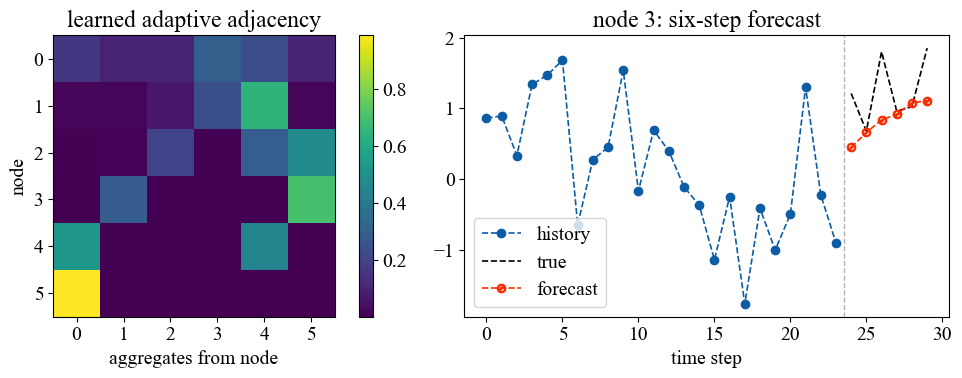

In [7]:
with torch.no_grad():
    A = model.adaptive_adj().numpy()
    pred = model(X_test)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(A, cmap="viridis")
ax[0].set_title("learned adaptive adjacency")
ax[0].set_xlabel("aggregates from node")
ax[0].set_ylabel("node")
ax[0].set_xticks(range(n_nodes))
ax[0].set_yticks(range(n_nodes))
fig.colorbar(im, ax=ax[0], fraction=0.046)

node = 3
hist = X_test[0, 0, node].numpy()
truth = Y_test[0, node].numpy()
fcst = pred[0, node].numpy()
ax[1].plot(range(L), hist, "C0", label="history")
ax[1].plot(range(L, L + H), truth, "k--", label="true")
ax[1].plot(range(L, L + H), fcst, "C3", label="forecast")
ax[1].axvline(L - 0.5, color="0.7", lw=1)
ax[1].set_title(f"node {node}: six-step forecast")
ax[1].set_xlabel("time step")
ax[1].legend()
fig.tight_layout()
plt.show()

The no-graph ablation makes the point that matters: switching the adaptive
adjacency on lowers test error even though no graph was supplied. Graph
WaveNet learns *that* the sensors are coupled and exploits it, all by
backprop through the same loss that trains the forecaster. The learned matrix
is the model's own answer to which series to mix, optimised for accuracy
rather than interpretability.